# Binning

Binning converts a continuous numeric variable into grouped categories called bins.

## Why we use it

- to reduce the effect of outliers
- to simplify continuous values
- to make patterns easier to understand

## Types of binning

- unsupervised binning
- supervised binning
- custom binning

In this notebook, we will focus on simple unsupervised binning.

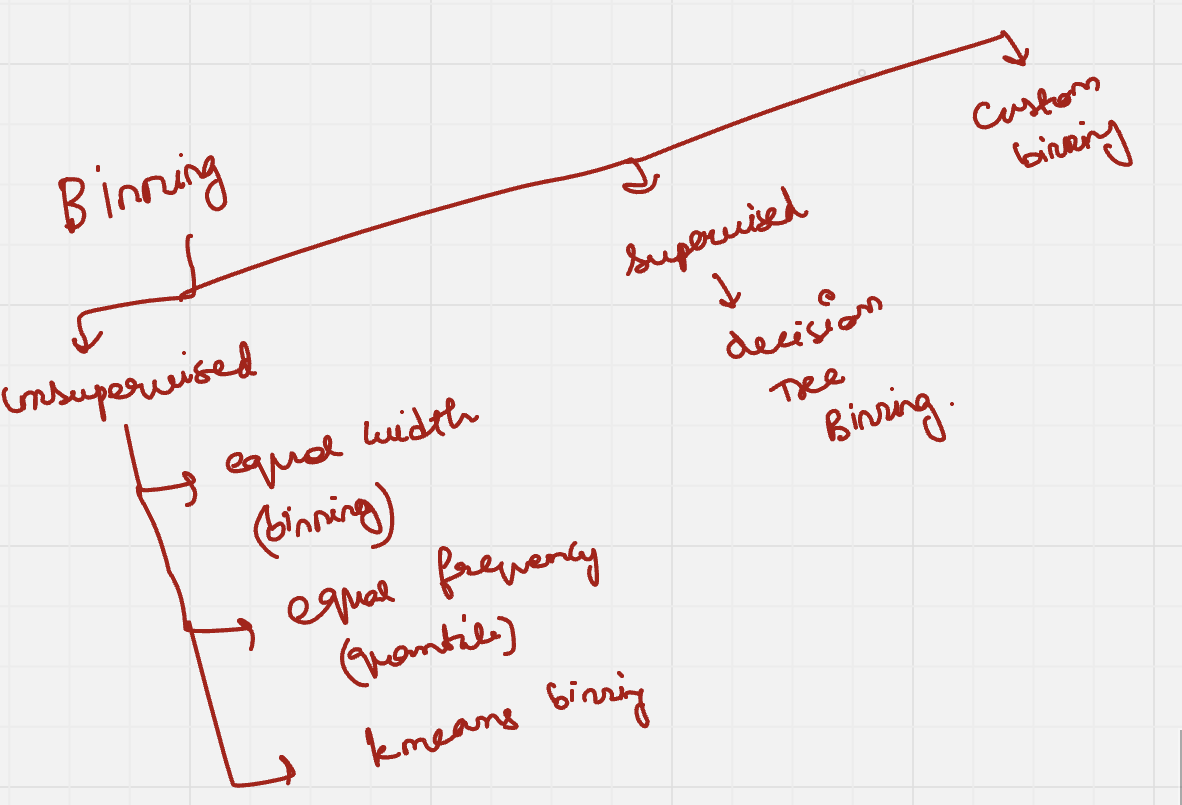

## Unsupervised Binning

Unsupervised binning does not use the target variable.

We will see three common methods:

- equal-width binning with `pd.cut()`
- equal-frequency binning with `pd.qcut()`
- K-means binning using clusters of similar values

We will also display the bins visually so the grouping is easier to compare.

In [7]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

# Create a small sample dataset
data = pd.DataFrame({
    'income': [15000, 18000, 22000, 27000, 32000, 40000, 52000, 68000, 85000, 110000]
})

# Common labels for all binning methods
bin_labels = ['Low', 'Medium', 'High']

# Helper function to add a binned column and return a new dataframe
def add_binned_column(frame, bin_column, binned_values):
    result = frame.copy()
    result[bin_column] = pd.Categorical(binned_values, categories=bin_labels, ordered=True)
    return result

# Equal-width binning function
def equal_width_binning(frame, column_name, bins=3):
    binned_values = pd.cut(frame[column_name], bins=bins, labels=bin_labels)
    return add_binned_column(frame, 'equal_width_bin', binned_values)

# Equal-frequency binning function
def equal_frequency_binning(frame, column_name, q=3):
    binned_values = pd.qcut(frame[column_name], q=q, labels=bin_labels)
    return add_binned_column(frame, 'equal_frequency_bin', binned_values)

# K-means binning function
def kmeans_binning(frame, column_name, clusters=3):
    kmeans = KMeans(n_clusters=clusters, random_state=42, n_init=10)
    cluster_ids = kmeans.fit_predict(frame[[column_name]])
    cluster_order = sorted(
        range(clusters),
        key=lambda cluster_id: kmeans.cluster_centers_[cluster_id][0]
    )
    cluster_name_map = {cluster_id: label for cluster_id, label in zip(cluster_order, bin_labels)}
    binned_values = pd.Series(cluster_ids, index=frame.index).map(cluster_name_map)
    return add_binned_column(frame, 'kmeans_bin', binned_values)

# Plot helper: histogram plus bar chart
def plot_binning_summary(frame, column_name, bin_column, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for label in bin_labels:
        group = frame[frame[bin_column] == label]
        if not group.empty:
            axes[0].hist(group[column_name], bins=5, alpha=0.7, label=label)

    axes[0].set_title(f'{title} - Histogram')
    axes[0].set_xlabel(column_name.capitalize())
    axes[0].set_ylabel('Count')
    axes[0].legend(title='Bin')

    counts = frame[bin_column].value_counts().reindex(bin_labels, fill_value=0)
    axes[1].bar(counts.index, counts.values, color=['#4c78a8', '#f58518', '#54a24b'])
    axes[1].set_title(f'{title} - Bin Counts')
    axes[1].set_xlabel('Bin')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

data

,income
0,15000
1,18000
2,22000
3,27000
4,32000
5,40000
6,52000
7,68000
8,85000
9,110000


Equal-width binning
   income equal_width_bin
0   15000             Low
1   18000             Low
2   22000             Low
3   27000             Low
4   32000             Low
5   40000             Low
6   52000          Medium
7   68000          Medium
8   85000            High
9  110000            High


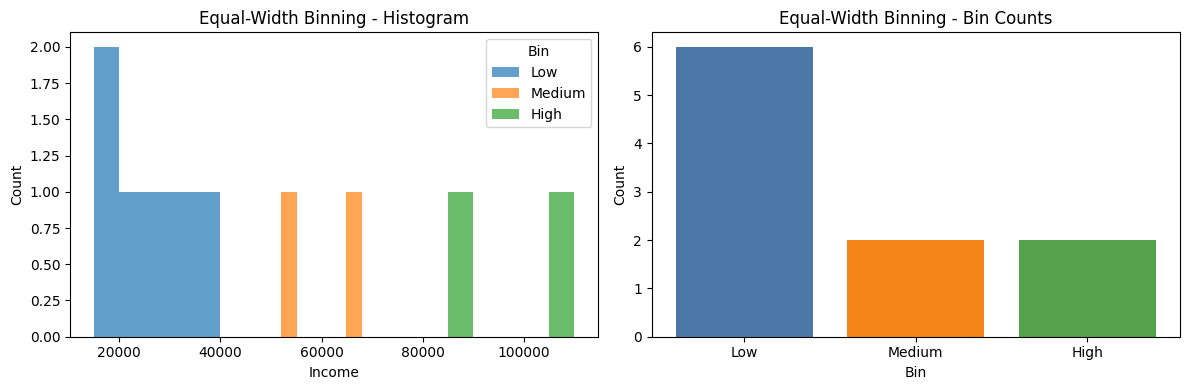

In [8]:
# Equal-width binning
equal_width_result = equal_width_binning(data, 'income')

print('Equal-width binning')
print(equal_width_result)
plot_binning_summary(equal_width_result, 'income', 'equal_width_bin', 'Equal-Width Binning')

## Equal-Frequency Binning

Equal-frequency binning puts a similar number of rows into each bin.

Equal-frequency binning
   income equal_frequency_bin
0   15000                 Low
1   18000                 Low
2   22000                 Low
3   27000                 Low
4   32000              Medium
5   40000              Medium
6   52000              Medium
7   68000                High
8   85000                High
9  110000                High


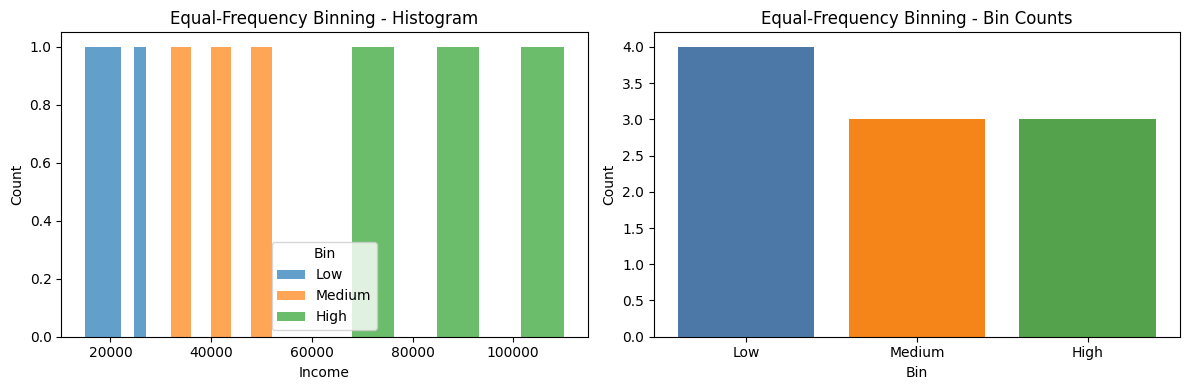

In [9]:
# Equal-frequency binning
equal_frequency_result = equal_frequency_binning(data, 'income')

print('Equal-frequency binning')
print(equal_frequency_result)
plot_binning_summary(equal_frequency_result, 'income', 'equal_frequency_bin', 'Equal-Frequency Binning')

## K-Means Binning

K-means binning groups values by similarity using cluster centers.

K-means binning
   income kmeans_bin
0   15000        Low
1   18000        Low
2   22000        Low
3   27000        Low
4   32000        Low
5   40000     Medium
6   52000     Medium
7   68000     Medium
8   85000       High
9  110000       High


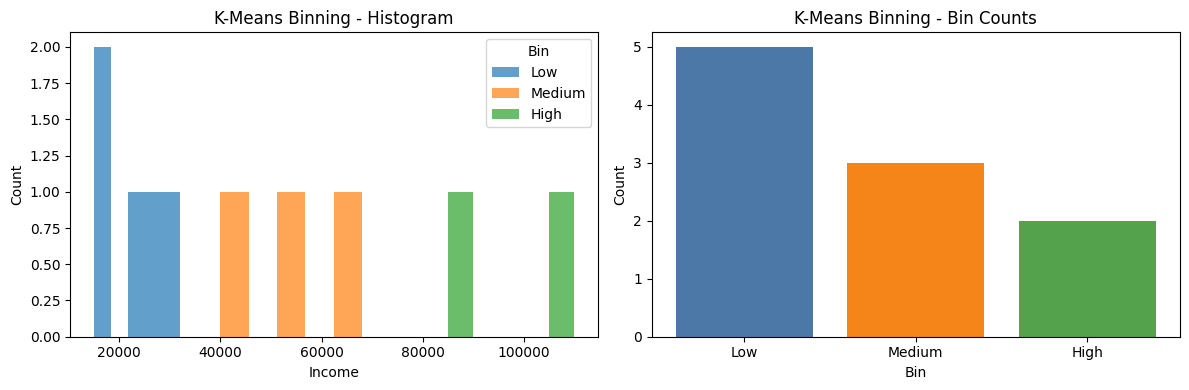

In [10]:
# K-means binning
kmeans_result = kmeans_binning(data, 'income')

print('K-means binning')
print(kmeans_result)
plot_binning_summary(kmeans_result, 'income', 'kmeans_bin', 'K-Means Binning')